# 02 — Preprocessing and augmentation

Raw signal → band-pass → 0.25 s windows @ 50 % overlap → per-segment z-score →
two augmented views (the positive pair for contrastive learning).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # run from notebooks/
%matplotlib inline

In [2]:
from preprocessing.cwru_manifest import select_records
from preprocessing.loader import load_signal
from preprocessing.filtering import filter_signal
from preprocessing.segmentation import preprocess_record
from config import CFG

sig = load_signal(select_records()[0])
filtered = filter_signal(sig.signal, sig.sampling_rate)
segments, rate = preprocess_record(sig.signal, sig.sampling_rate)
print("band-pass", CFG.preprocess.filter_low_hz, "-", CFG.preprocess.filter_high_hz, "Hz")
print("segments:", segments.shape, "@", rate, "Hz")
print("per-segment mean/std:", segments[0].mean().round(12), segments[0].std().round(6))

band-pass 10.0 - 5000.0 Hz
segments: (39, 3000) @ 12000 Hz
per-segment mean/std: 6.36e-10 1.0


Why 10–5000 Hz and no decimation: an earlier version decimated by 4, which put
Nyquist at 1.5 kHz and discarded the 2–4 kHz bearing resonances that carry most
of the fault signature.

corr(view A, original) = -0.392


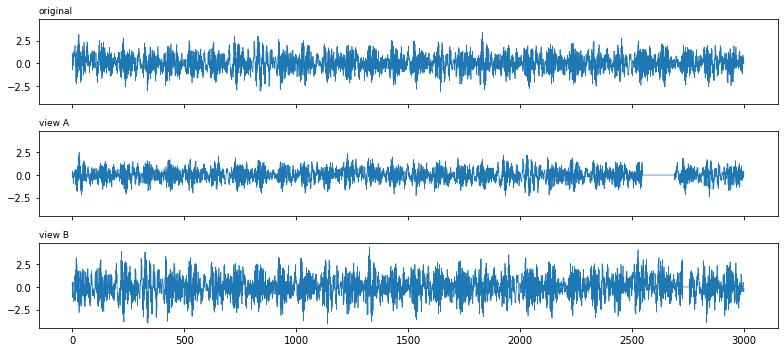

In [3]:
import numpy as np, matplotlib.pyplot as plt
from preprocessing.augmentation import make_two_views
rng = np.random.default_rng(0)
a, b = make_two_views(segments[0], rng=rng)
fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True, sharey=True)
for ax, (name, x) in zip(axes, [("original", segments[0]), ("view A", a), ("view B", b)],
                         strict=True):
    ax.plot(x, lw=.7); ax.set_title(name, loc="left", fontsize=9)
plt.tight_layout()
print("corr(view A, original) =", round(float(np.corrcoef(a, segments[0])[0, 1]), 3))

The cached segment array for the whole dataset is built once from the shell:

```bash
PYTHONPATH=. python -m preprocessing.build_dataset
```